In [1]:
import torch

In [2]:
print(torch.cuda.is_available())

True


CNN foundations using MNIST dataset

In [3]:
from torchvision import datasets, transforms #loads datasets and preprocesses images

In [4]:
transform = transforms.Compose([
    transforms.ToTensor()
])

In [5]:
train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.57MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 126kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.19MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.3MB/s]


In [6]:
print(len(train_dataset))

60000


In [7]:
image, label = train_dataset[0]

print(image.shape)
print(label)

torch.Size([1, 28, 28])
5


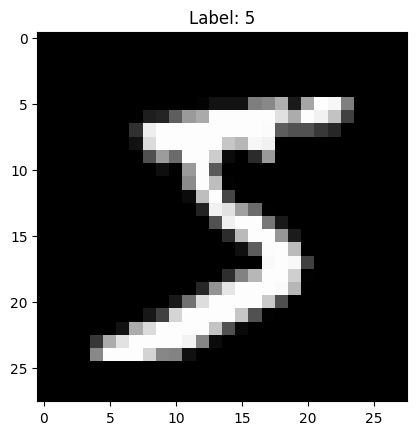

In [8]:
import matplotlib.pyplot as plt

plt.imshow(image.squeeze(), cmap='gray')
plt.title(f"Label: {label}")
plt.show()

In [9]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

In [10]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([32, 1, 28, 28])
torch.Size([32])


In [11]:
import torch.nn as nn   #has nn layers
import torch.nn.functional as F   #activation func like ReLU

In [12]:
class SimpleCNN(nn.Module):
  def __init__(self):
    super(SimpleCNN, self).__init__()

    self.conv1=nn.Conv2d(
        in_channels=1,
        out_channels=32,
        kernel_size=3
    )

    self.pool = nn.MaxPool2d(kernel_size=2)
    self.fc1=nn.Linear(32*13*13, 128)
    self.fc2=nn.Linear(128,10)

  def forward(self, x):
    x=self.pool(F.relu(self.conv1(x)))
    x=x.view(x.size(0),-1)
    x=F.relu(self.fc1(x))
    x=self.fc2(x)

    return x

In [13]:
model=SimpleCNN()

print(model)

SimpleCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=5408, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [14]:
criterion = nn.CrossEntropyLoss()

In [15]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

print(device)

cuda


In [17]:
epochs=3
for epoch in range(epochs):
  running_loss=0.0

  for images,labels in train_loader:
    images=images.to(device)
    labels=label=labels.to(device)

    optimizer.zero_grad()

    outputs=model(images)

    loss=criterion(outputs,labels)

    loss.backward()
    optimizer.step()
    running_loss+=loss.item()

    print(f"Epoch[{epoch+1}/{epochs}],Loss:{running_loss:.4f}")

Streaming output truncated to the last 5000 lines.
Epoch[1/3],Loss:209.3225
Epoch[1/3],Loss:209.4768
Epoch[1/3],Loss:209.7935
Epoch[1/3],Loss:209.9244
Epoch[1/3],Loss:209.9726
Epoch[1/3],Loss:210.0255
Epoch[1/3],Loss:210.2466
Epoch[1/3],Loss:210.2821
Epoch[1/3],Loss:210.5088
Epoch[1/3],Loss:210.6643
Epoch[1/3],Loss:210.8600
Epoch[1/3],Loss:210.9942
Epoch[1/3],Loss:211.2220
Epoch[1/3],Loss:211.4632
Epoch[1/3],Loss:211.5696
Epoch[1/3],Loss:211.7921
Epoch[1/3],Loss:211.9465
Epoch[1/3],Loss:212.1388
Epoch[1/3],Loss:212.2330
Epoch[1/3],Loss:212.3110
Epoch[1/3],Loss:212.5016
Epoch[1/3],Loss:212.6073
Epoch[1/3],Loss:212.6359
Epoch[1/3],Loss:212.9355
Epoch[1/3],Loss:213.1295
Epoch[1/3],Loss:213.2581
Epoch[1/3],Loss:213.4491
Epoch[1/3],Loss:213.5927
Epoch[1/3],Loss:213.9579
Epoch[1/3],Loss:214.0748
Epoch[1/3],Loss:214.2614
Epoch[1/3],Loss:214.4683
Epoch[1/3],Loss:214.6681
Epoch[1/3],Loss:214.7494
Epoch[1/3],Loss:215.0913
Epoch[1/3],Loss:215.1779
Epoch[1/3],Loss:215.3093
Epoch[1/3],Loss:215.6743

In [18]:
model.eval()

SimpleCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=5408, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

In [19]:
correct = 0
total = 0

In [20]:
with torch.no_grad():

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

In [21]:
accuracy = 100 * correct / total

print(f"Accuracy: {accuracy:.2f}%")

Accuracy: 99.02%


In [22]:
images, labels = next(iter(train_loader))

images = images.to(device)
labels = labels.to(device)

outputs = model(images)

_, predicted = torch.max(outputs, 1)

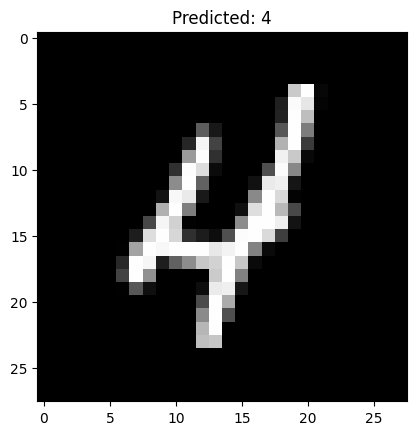

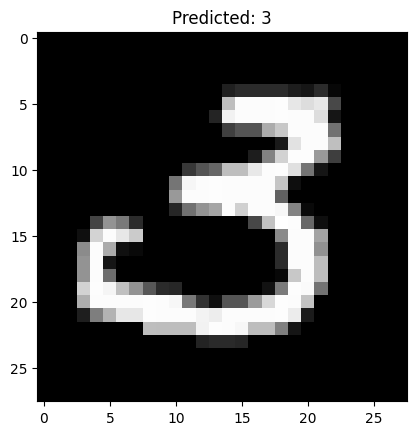

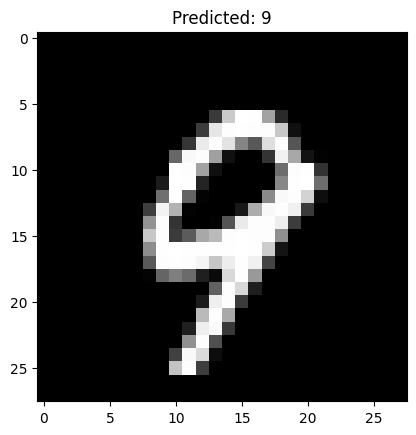

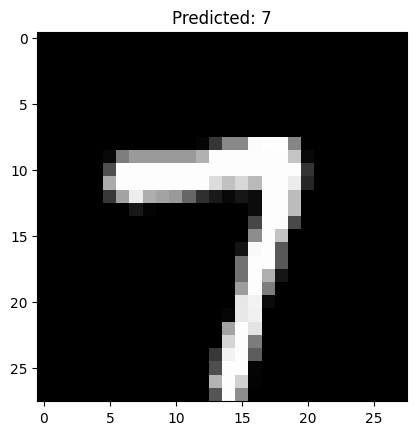

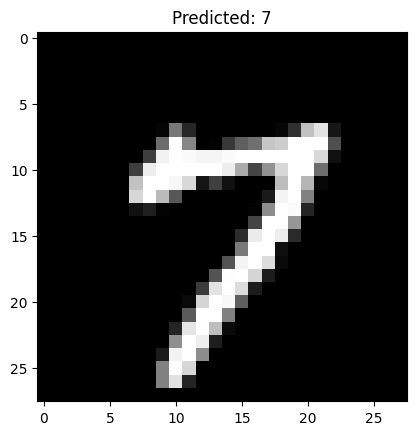

In [23]:
import matplotlib.pyplot as plt

for i in range(5):

    plt.imshow(images[i].cpu().squeeze(), cmap='gray')

    plt.title(f"Predicted: {predicted[i].item()}")

    plt.show()

# Brain Tumor MRI classification using Deep Learning
### Loading MRI dataset

In [25]:
import zipfile
zip_ref=zipfile.ZipFile('/content/MRIdataset.zip','r')
zip_ref.extractall('/content')
zip_ref.close()

In [26]:
import os
print(os.listdir('/content/'))

['.config', 'Training', 'MRIdataset.zip', 'data', 'Testing', 'sample_data']


In [27]:
print(os.listdir('/content/Training'))

['meningioma', 'pituitary', 'glioma', 'notumor']


In [28]:
print(os.listdir('/content/Testing'))

['meningioma', 'pituitary', 'glioma', 'notumor']


In [29]:
from torchvision.datasets import ImageFolder
from torchvision import transforms

### Image Preprocessing

In [30]:
transform=transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

In [31]:
train_dataset=ImageFolder(
    root='/content/Training',
    transform=transform
)

In [32]:
test_dataset=ImageFolder(
    root='/content/Testing',
    transform=transform
)

In [33]:
print("Training Images:", len(train_dataset))
print("Testing Images:",len(test_dataset))

print("Classes:",train_dataset.classes)

Training Images: 5600
Testing Images: 1600
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


### 8. Visualize Predictions

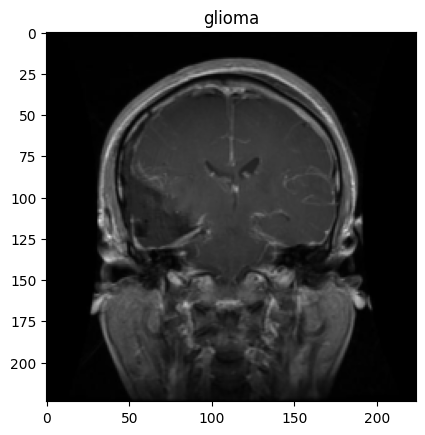

In [34]:
import matplotlib.pyplot as plt

image,label=train_dataset[0]
plt.imshow(image.permute(1,2,0))
plt.title(train_dataset.classes[label])
plt.show()

In [35]:
from torch.utils.data import DataLoader


### Creating Dataloaders

In [37]:
train_loader=DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True  #randomizes image order during training
)

test_loader=DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False  #no random order required
)

In [38]:
images,labels=next(iter(train_loader))
print(images.shape)
print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


In [39]:
from torchvision import models

In [40]:
model=models.resnet18(pretrained=True)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 44.7M/44.7M [00:00<00:00, 194MB/s]


In [41]:
import torch.nn as nn
model.fc=nn.Linear(model.fc.in_features,4)

In [42]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
model=model.to(device)
print(device)

cuda


In [43]:
criterion=nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [44]:
epochs=5
for epoch in range(epochs):
  model.train()
  running_loss=0.0

  correct=0
  total=0

  for images,labels in train_loader:
    images=images.to(device)
    labels=labels.to(device)

    optimizer.zero_grad()
    outputs=model(images)
    loss=criterion(outputs, labels)
    loss.backward()
    optimizer.step()
    running_loss+=loss.item()
    _,predicted=torch.max(outputs,1)
    total+=labels.size(0)
    correct+=(predicted==labels).sum().item()
  epoch_accuracy=100*correct/total

  print(f"Epoch[{epoch+1}/{epochs}]")
  print(f"Loss: {running_loss:.4f}")
  print(f"Accuracy: {epoch_accuracy:.2f}%")

Epoch[1/5]
Loss: 56.0458
Accuracy: 88.84%
Epoch[2/5]
Loss: 28.3568
Accuracy: 94.16%
Epoch[3/5]
Loss: 21.0351
Accuracy: 95.96%
Epoch[4/5]
Loss: 14.6756
Accuracy: 96.91%
Epoch[5/5]
Loss: 11.9413
Accuracy: 97.45%


### Evaulating Model Performance

In [46]:
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [47]:
total=0
correct=0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

In [48]:
accuracy = 100 * correct / total

print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 78.25%


### Visualize Predictions

In [49]:
images, labels = next(iter(test_loader))

images = images.to(device)
labels = labels.to(device)

outputs = model(images)

_, predicted = torch.max(outputs, 1)

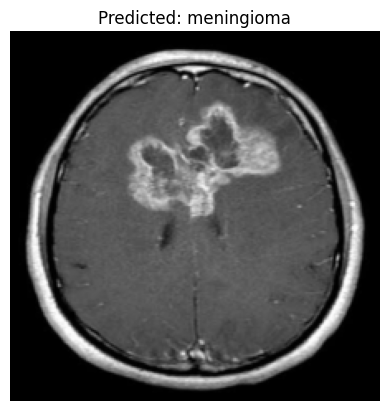

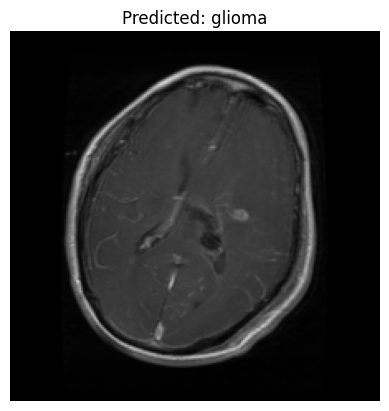

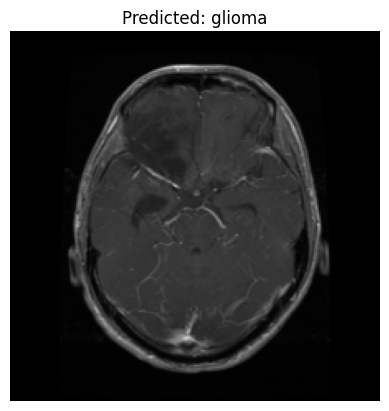

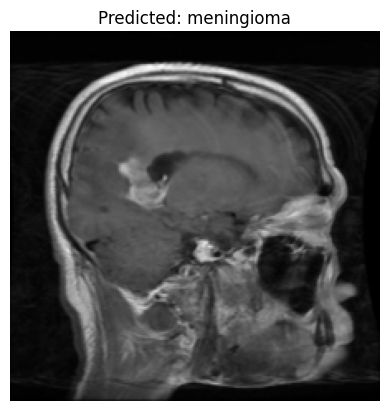

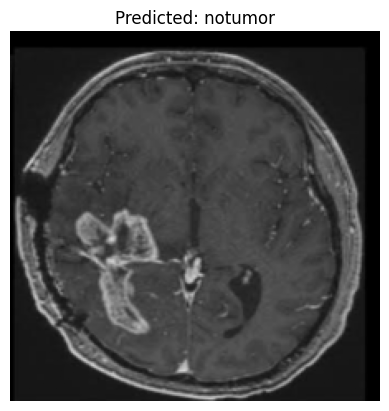

In [50]:
import matplotlib.pyplot as plt

class_names = train_dataset.classes

for i in range(5):

    plt.imshow(images[i].cpu().permute(1,2,0))

    plt.title(f"Predicted: {class_names[predicted[i]]}")

    plt.axis('off')

    plt.show()